This folder is sandboxed from the rest of the emulator, intended to test final emulator predictions using exact parameters.

In [1]:
saved_seds = []

In [1]:
from tardis.io.configuration.config_reader import Configuration
from tardis.simulation import Simulation
from emulator.grid_run.make_csvy import make_csvy, make_abundances
from emulator.grid_run.run_tardis import set_threads
import astropy.constants as c
import astropy.units as u
import os

log_scale =  52.33831163468587
data =  {'log_lsun': 8.334207183569124, 't_exp': 17.499252278542855, 'v_start': 5862.778796683932, 'X': 0.550034701281516, 'Z': 0.013024760352725219, 'n': 10.999786025155966}

log_lsun = data['log_lsun']
t_exp = data['t_exp'] * u.day
v_start = data['v_start'] * u.km/u.s
X = data['X']
Z = data['Z']
n = data['n']
scale = 10**log_scale

# Run simulation
set_threads(4)
sandbox_dir = os.path.abspath('.')
config_path = os.path.join(sandbox_dir, 'config.yml')
make_csvy(
    v_start,
    v_stop=v_start*3,
    shells=40,
    n=n,
    config_path=config_path,
    abundances=make_abundances(X, Z)
)
config = Configuration.from_yaml(config_path)
config.supernova.luminosity_requested = 10**log_lsun * c.L_sun
config.supernova.time_explosion = t_exp

sim = Simulation.from_config(
    config,
    virtual_packet_logging=False,
    show_convergence_plots=False,
    export_convergence_plots=False,
    log_level='DEBUG'
)
sim.run_convergence()
sim.run_final()

Iterations:          0/? [00:00<?, ?it/s]

Packets:             0/? [00:00<?, ?it/s]

Initializing tabulator and plotly panel extensions for widgets to work


Zeta_data missing - replaced with 1s. Missing ions: [(12, 13), (14, 15), (16, 17), (26, 27)]
Zeta_data missing - replaced with 1s. Missing ions: [(12, 13), (14, 15), (16, 17), (26, 27)]
/home/mikel/GitHub/tardis/tardis/transport/montecarlo/montecarlo_main_loop.py:146: NumbaTypeSafetyWarning:

unsafe cast from uint64 to int64. Precision may be lost.



In [ ]:
print(sim.plasma.plasma_properties_dict.keys())
print(sim.plasma.t_rad)

dict_keys(['DilutePlanckianRadField', 'NumberDensity', 'TimeExplosion', 'AtomicData', 'JBlues', 'LinkTRadTElectron', 'HeliumTreatment', 'ContinuumInteractionSpecies', 'NLTEIonizationSpecies', 'NLTEExcitationSpecies', 'TRadiative', 'DilutionFactor', 'BetaRadiation', 'Levels', 'Lines', 'PartitionFunction', 'GElectron', 'IonizationData', 'LinesLowerLevelIndex', 'LinesUpperLevelIndex', 'TauSobolev', 'StimulatedEmissionFactor', 'SelectedAtoms', 'ElectronTemperature', 'LevelBoltzmannFactorDiluteLTE', 'PhiSahaNebular', 'ZetaData', 'BetaElectron', 'RadiationFieldCorrection', 'LevelBoltzmannFactorNoNLTE', 'BetaSobolev', 'TransitionProbabilities', 'MacroAtomData', 'LevelNumberDensity', 'IonNumberDensity'])
[10456.29148217 10472.72051442 10488.85826101 10521.41993716
 10586.5300724  10650.94283362 10662.21639372 10727.91915526
 10737.53893447 10756.69193918 10812.34557325 10837.20567033
 10862.08068165 10844.16195828 10839.84979005 10840.00398966
 10750.27407959 10681.26759036 10595.30546481 1042

7609.0866464947985


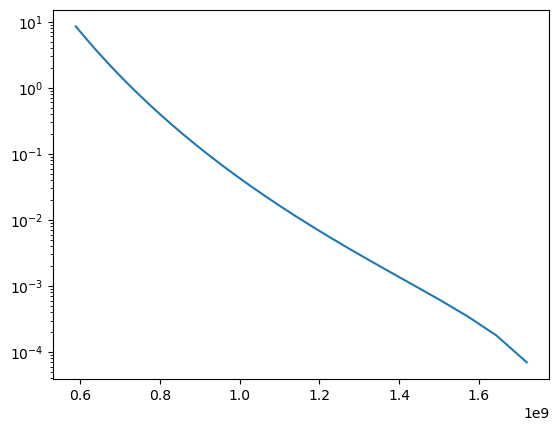

In [ ]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np

# Compute Thomson optical depth
n_e = sim.plasma.electron_densities
sigma_T = c.sigma_T.cgs.value
kappa = n_e * sigma_T
v = ((sim.simulation_state.v_outer + sim.simulation_state.v_inner) / 2).cgs.value
dr = (sim.simulation_state.r_outer - sim.simulation_state.r_inner).cgs.value
tau = np.flip(np.cumsum(np.flip(kappa * dr)))
v_ph = (interp1d(tau, v)(2/3) *u.cm/u.s).to(u.km/u.s).value

print(v_ph)

plt.plot(v, tau)
plt.yscale('log')
plt.show()

7543.734526685361 km / s


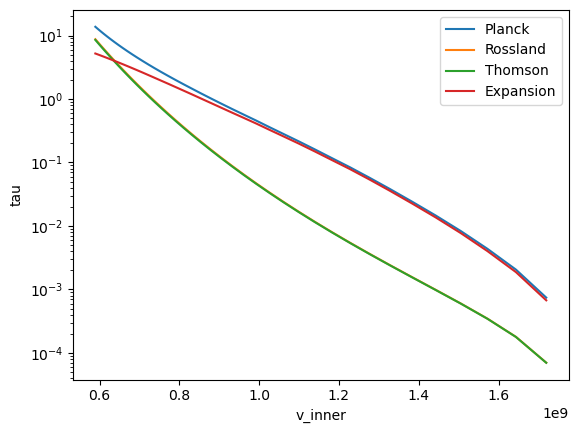

In [ ]:
from emulator.grid_run.run_tardis import get_tau, get_phot

v, tau_thomson, tau_expansion, tau_planck, tau_rosseland = get_tau(sim, t_exp.value, plot=True)
v_phot, T_phot = get_phot(sim, v, tau_rosseland)
print(v_phot, T_phot)

In [ ]:
import subprocess
subprocess.run([
    'powershell.exe',
    '-c',
    '(New-Object Media.SoundPlayer "C:/Windows/Media/Alarm10.wav").PlaySync()'
])

CompletedProcess(args=['powershell.exe', '-c', "(New-Object Media.SoundPlayer 'C:/Windows/Media/Alarm10.wav').PlaySync()"], returncode=0)

In [8]:
spectrum = sim.spectrum_solver.spectrum_integrated
saved_seds.append(spectrum.luminosity_density_lambda.value)

The formal integral implementation was not specified. Please run with config option numba or cuda.Defaulting to numba implementation.
The number of interpolate_shells was not specified. The value was set to 80.


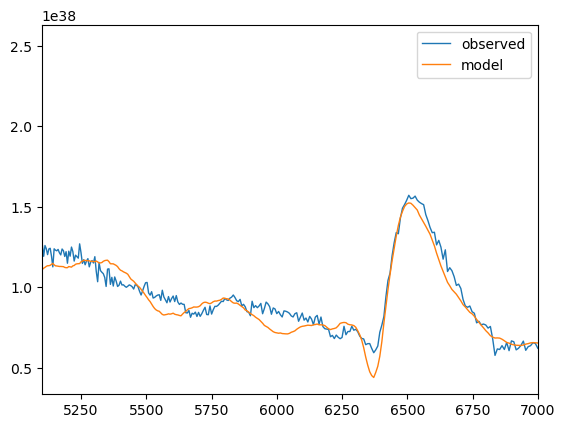

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

spectrum = sim.spectrum_solver.spectrum_integrated
# y_mod = spectrum.luminosity_density_lambda.value
y_mod = saved_seds[0]
wav = spectrum.wavelength.value

# Get observed data
from scipy.interpolate import interp1d
obs_df = pd.read_csv(r'/home/mikel/GitHub/iip-emulator/emulator/interpolator/calibrated_spectra/2020jfo-2020-05-19.csv', comment='#')
y_obs = interp1d(obs_df['wavelength'], obs_df['flux'], bounds_error=False)(wav)
y_obs_err = interp1d(obs_df['wavelength'], obs_df['fluxerr'], bounds_error=False)(wav)

mask = ~np.isnan(y_obs)
wav = wav[mask]
y_obs = y_obs[mask]
y_mod = y_mod[mask]
y_obs_err = y_obs_err[mask]

plt.plot(wav, y_obs*scale, label='observed', lw=1)
plt.plot(wav, y_mod, label='model', lw=1)
plt.legend()
plt.xlim(5100, 7000)
plt.show()

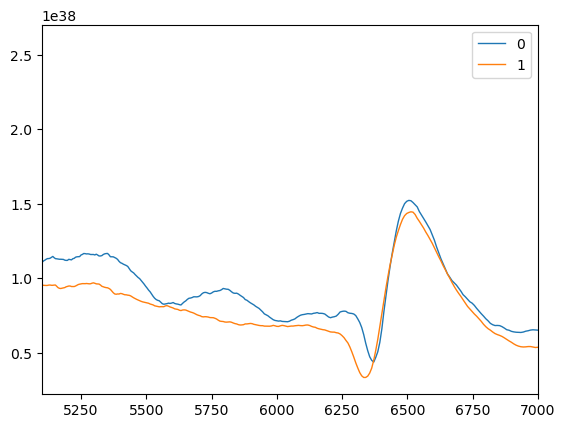

In [9]:
# Display all saved
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

wav = spectrum.wavelength.value

i = 0
for y_mod in saved_seds:
    plt.plot(wav, y_mod, lw=1, label=i)
    i += 1
plt.xlim(5100, 7000)
plt.legend()
plt.show()

[ 5200.          5475.52943498  5826.97533949  6275.2549355
  6847.04875532  7576.38860323  8506.68304734  9693.30099399
 11206.86711303 13137.46524964 15600.        ]


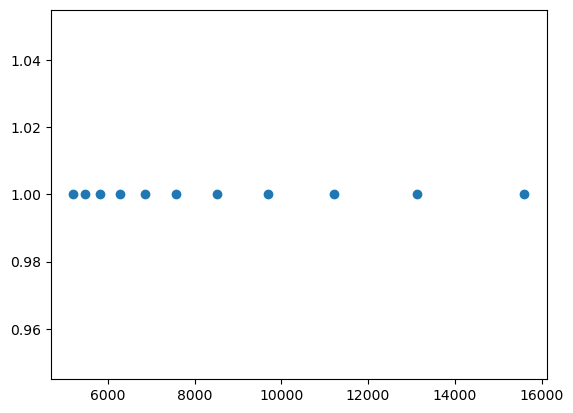

In [26]:
log_start = 3
start = 5200
stop = start * 3
shells = 10
v = (np.logspace(log_start, np.log10(stop-start+10**log_start), num=shells+1) + start - 10**log_start)
print(v)
plt.scatter(v, np.ones_like(v))
plt.show()

In [ ]:
for y_mod in saved_seds:
    y_mod = y_mod[mask]

    # Find best fit scale
    def f(x):
        scale = x[0]
        y1 = y_mod
        y2 = y_obs*scale
        fe = np.abs(y1 - y2)/y2
        mean_fe = np.mean(fe)
        mse = np.mean((y1-y2)**2)
        return mse

    from scipy.optimize import differential_evolution
    scale_guess = np.max(y_mod) / np.max(y_obs)
    result = differential_evolution(f, x0=[scale_guess], bounds=[(10**50, 10**60)])
    scale = result.x[0]
    distance = np.sqrt(scale/4/np.pi) * u.cm
    print('scale guess:', scale_guess)
    print('scale:', scale)
    print('distance:', distance.to(u.Mpc))

    plt.plot(wav, y_mod, label='model')
    plt.plot(wav, y_obs*scale, label='observed')
    plt.legend()
    plt.show()

In [ ]:
#print(sim.plasma.plasma_properties_dict.keys())
print(sim.plasma.dilute_planckian_radiation_field.temperature_kelvin)
print(sim.converged)
print(sim.iterations_executed)
print(sim.iterations_t_inner)